# 04 -- Country Analysis

## Research Question
Who depends on whom, and how concentrated is that dependency?

## Data
World Bank (import dependency, GDP), UN Comtrade (export-partner concentration), World Bank LPI (logistics). All PUBLIC; concentration metrics DERIVED.

## Method
Import dependency = merchandise imports / GDP. Export-partner concentration = HHI of each country's 2023 export destinations within the network. See `python/analysis/risk_index.py` for the full four-pillar Supply Chain Risk Index this feeds into.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys, os
sys.path.insert(0, os.path.abspath('../python/visualisation'))
pd.set_option('display.max_columns', 20)

In [2]:
risk = pd.read_csv('../data/processed/supply_chain_risk_index.csv')
print("Most export-concentrated economies (highest HHI-based score):")
print(risk.sort_values('score_trade_concentration', ascending=False)[['Country','score_trade_concentration']].head(10).to_string(index=False))

Most export-concentrated economies (highest HHI-based score):
             Country  score_trade_concentration
            Mongolia                 100.000000
    Macao SAR, China                  94.797103
                Iraq                  72.357268
Hong Kong SAR, China                  52.850053
          Azerbaijan                  41.181933
              Angola                  34.628692
               Chile                  29.782303
           Australia                  26.045789
              Poland                  25.395628
                Peru                  24.666770


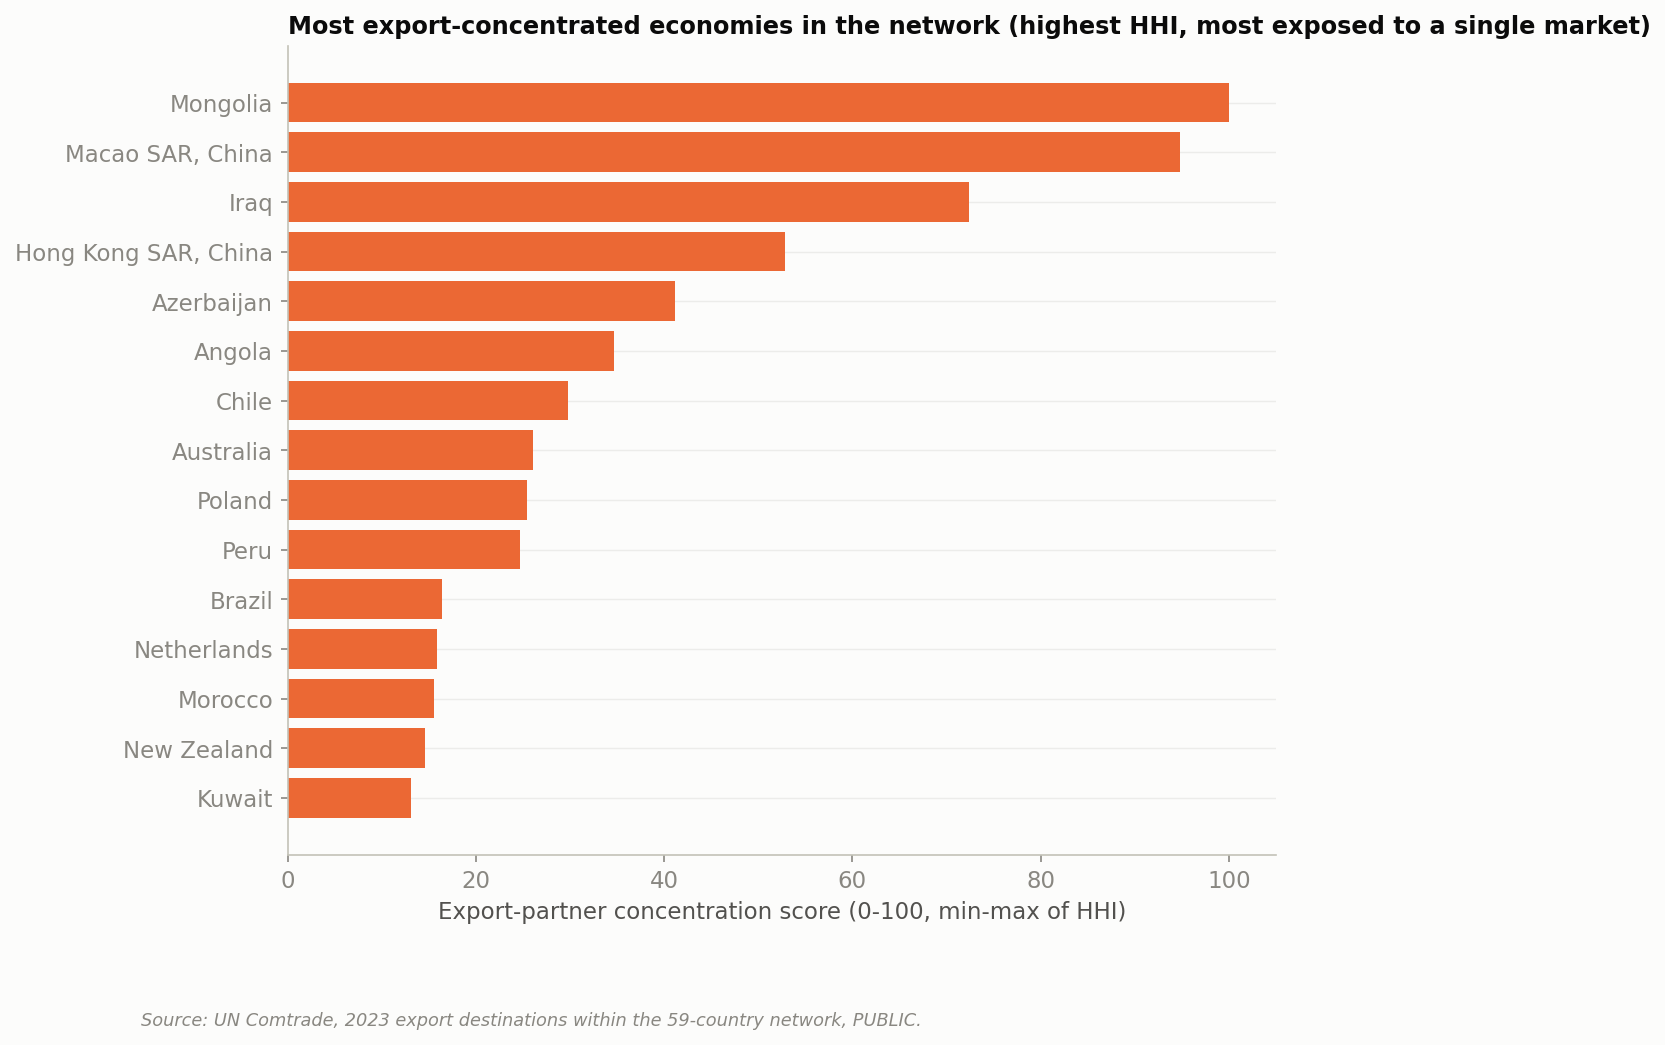

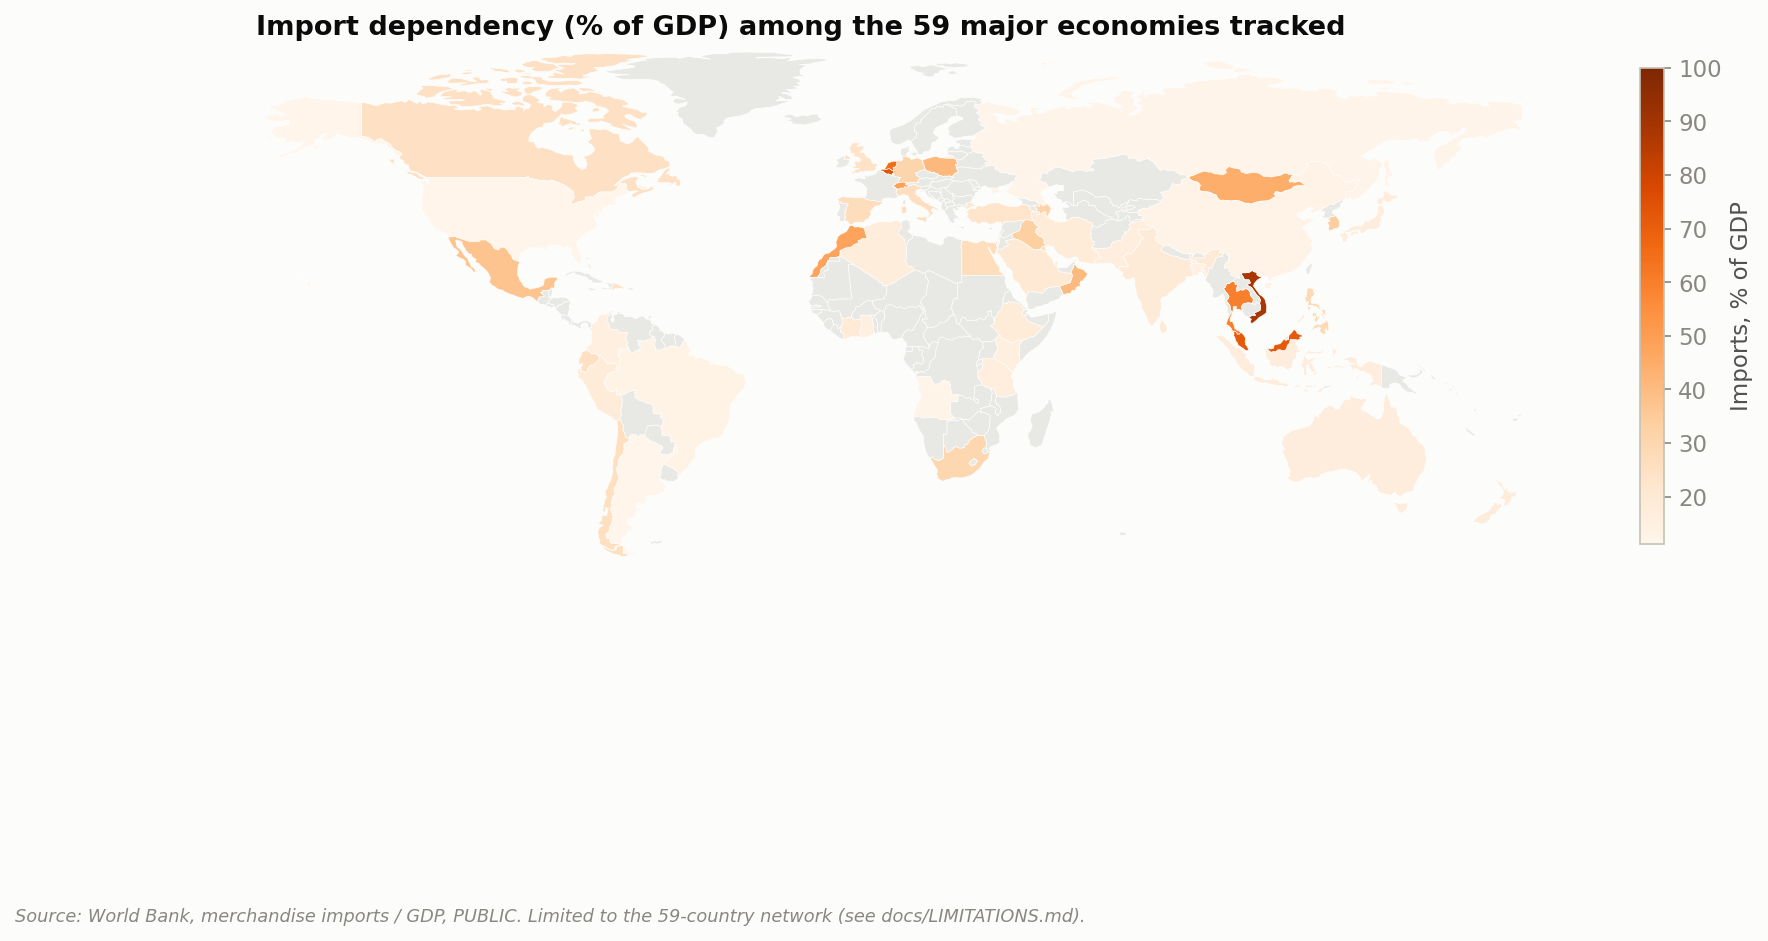

In [3]:
display(Image('../outputs/figures/05_trade_concentration.png', width=700))
display(Image('../outputs/figures/04_country_dependency_map.png', width=750))

## Finding

Export-partner concentration and import dependency are genuinely different dimensions of exposure -- a country can be highly import-dependent (a large share of GDP) while having a well-diversified set of suppliers, or vice versa. The full Supply Chain Risk Index (Notebook 07) combines both with logistics fragility and commodity exposure into one transparent composite.

## Limitation

Export-partner concentration is computed only within the 59/57-country network, not against a country's true full set of global trading partners.

## Next Step

Notebook 05 goes deeper into a specific, high-stakes dependency: critical raw materials.